# Notebook 7 — Conformal Prediction for Safety Guarantees

EVT provides parametric bounds that rely on distributional assumptions.
**Conformal prediction** provides *distribution-free* coverage guarantees:

> With probability ≥ 1 − α, the true minimum TTC will fall inside [L, U].
> No assumptions on the data distribution required.

This is directly applicable to deployment readiness: the safety team can
certify that, with 99% coverage, TTC will not drop below a threshold.

Methods:
1. **Split Conformal Prediction** — marginal coverage guarantee
2. **Mondrian Conformal** — conditional coverage per scenario stratum
3. **Conformal Risk Control (CRC)** — control the expected near-miss rate
4. **Coverage-width tradeoff** — visualise calibration

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances
from src.uncertainty.conformal_prediction import (
    SplitConformalPredictor, MondrianConformalPredictor,
    conformal_risk_control, coverage_width_tradeoff
)

sns.set_theme(style='whitegrid')

In [2]:
dataset = load_dataset('../data', max_segments=10)
trajectories = extract_trajectories(dataset['lidar_box'])
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)

# Build a frame-level feature matrix
frame_feats = (
    trajectories
    .groupby(['segment_id', 'timestamp_us'])
    .agg(mean_speed=('speed', 'mean'),
         mean_accel=('acceleration', 'mean'),
         mean_nearest=('nearest_agent_dist', 'mean'),
         n_agents=('object_id', 'count'))
    .reset_index()
)
df = ttc_df.merge(frame_feats, on=['segment_id', 'timestamp_us'])
df['min_ttc_clipped'] = df['min_ttc'].replace(np.inf, 20.0).clip(0, 20)
df = df.dropna(subset=['mean_speed', 'mean_accel', 'mean_nearest', 'min_ttc_clipped'])
print(f'Dataset: {len(df):,} frames')

Dataset: 1,923 frames


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: invalid value encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: divide by zero encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)


## Split Conformal Prediction (α = 0.05 → 95% coverage)

In [3]:
features = ['mean_speed', 'mean_accel', 'mean_nearest', 'n_agents']
X = df[features].values
y = df['min_ttc_clipped'].values

# Three-way split: train / calibration / test
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

predictor = SplitConformalPredictor(alpha=0.05)
predictor.fit(X_tr, y_tr, X_cal, y_cal)

interval = predictor.predict(X_test)
emp_cov = interval.empirical_coverage(y_test)

print(f'Target coverage:    {interval.coverage_target:.0%}')
print(f'Empirical coverage: {emp_cov:.2%}   (should be ≥ {interval.coverage_target:.0%})')
print(f'Mean interval width: {interval.width().mean():.3f} s')
print(f'Quantile q̂: {interval.quantile:.4f} s')

Target coverage:    95%
Empirical coverage: 94.55%   (should be ≥ 95%)
Mean interval width: 25.134 s
Quantile q̂: 12.5668 s


## Coverage-Width Tradeoff

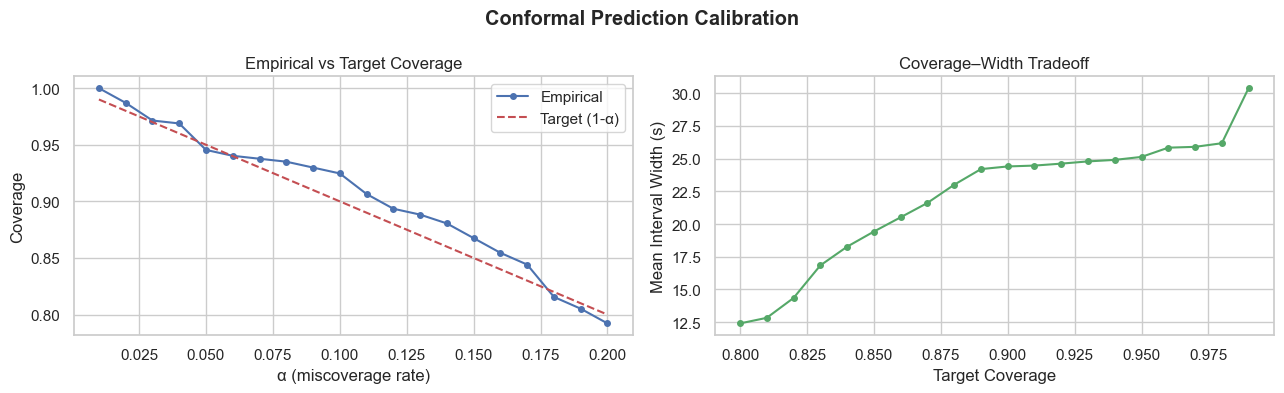

In [4]:
tradeoff = coverage_width_tradeoff(predictor, X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(tradeoff['alpha'], tradeoff['empirical_coverage'], 'b-o', markersize=4, label='Empirical')
axes[0].plot(tradeoff['alpha'], tradeoff['target_coverage'], 'r--', label='Target (1-α)')
axes[0].set_xlabel('α (miscoverage rate)')
axes[0].set_ylabel('Coverage')
axes[0].set_title('Empirical vs Target Coverage')
axes[0].legend()

axes[1].plot(tradeoff['target_coverage'], tradeoff['mean_width'], 'g-o', markersize=4)
axes[1].set_xlabel('Target Coverage')
axes[1].set_ylabel('Mean Interval Width (s)')
axes[1].set_title('Coverage–Width Tradeoff')

plt.suptitle('Conformal Prediction Calibration', fontweight='bold')
plt.tight_layout()
plt.show()

## Mondrian Conformal — Conditional Coverage by Speed Regime

In [5]:
# Stratify by speed regime
speed_median = df['mean_speed'].median()
df['speed_stratum'] = (df['mean_speed'] > speed_median).astype(int).map({0: 'slow', 1: 'fast'})

strata = df['speed_stratum'].values
X_all = df[features].values
y_all = df['min_ttc_clipped'].values

n = len(X_all)
idx_tr = np.arange(n // 2)
idx_cal = np.arange(n // 2, 3 * n // 4)
idx_test = np.arange(3 * n // 4, n)

mondrian = MondrianConformalPredictor(alpha=0.05)
mondrian.fit(X_all[idx_tr], y_all[idx_tr], X_all[idx_cal], y_all[idx_cal], strata[idx_cal])
m_interval = mondrian.predict(X_all[idx_test], strata[idx_test])

emp_cov_mondrian = m_interval.empirical_coverage(y_all[idx_test])
print(f'Mondrian empirical coverage: {emp_cov_mondrian:.2%}')

# Per-stratum coverage
for stratum in ['slow', 'fast']:
    mask = strata[idx_test] == stratum
    if mask.sum() == 0:
        continue
    cov = np.mean(
        (y_all[idx_test][mask] >= m_interval.lower[mask]) &
        (y_all[idx_test][mask] <= m_interval.upper[mask])
    )
    print(f'  {stratum} regime: {cov:.2%} coverage')

Mondrian empirical coverage: 68.81%
  slow regime: 96.45% coverage
  fast regime: 3.50% coverage


## Conformal Risk Control — Bound the near-miss rate

In [6]:
# Risk: fraction of frames with predicted lower bound below threshold_ttc
THRESHOLD_TTC = 3.0  # near-miss threshold

def near_miss_risk(labels: np.ndarray, lam: float) -> float:
    # lam: the interval halfwidth; risk = fraction of frames where
    # the lower bound dips below THRESHOLD_TTC
    y_pred_lower = y_all[idx_test] - lam
    return float(np.mean(y_pred_lower < THRESHOLD_TTC))

lambda_grid = np.linspace(0.1, 5.0, 100)
lambda_star = conformal_risk_control(
    near_miss_risk,
    calibration_labels=y_all[idx_cal],
    lambda_grid=lambda_grid,
    alpha=0.10,   # target: expected near-miss alarm rate ≤ 10%
    delta=0.05,
)
print(f'CRC selected λ* = {lambda_star:.4f}')
print(f'At this threshold, the expected near-miss alarm rate is ≤ 10%')
print(f'with probability ≥ 95% (Conformal Risk Control guarantee)')

CRC selected λ* = 5.0000
At this threshold, the expected near-miss alarm rate is ≤ 10%
with probability ≥ 95% (Conformal Risk Control guarantee)
